In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy import stats


In [91]:
loan_df = pd.read_csv("Bank_Personal_Loan_Modelling.csv")

In [92]:
loan_df.head(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [93]:
loan_df.shape

(5000, 14)

In [94]:
# This shows dtypes, so no need to use function "df.dtypes"
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [95]:
loan_df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [96]:
loan_df.isnull().values.any()

False

In [97]:
# There appears to be no null values

# 2) EDA

In [98]:
# Function to print number of unique values in all columns 
def nun_print (df):
    for col in df:
        print(col, pd.Series.nunique(loan_df[col]))
    
nun_print(loan_df)

ID 5000
Age 45
Experience 47
Income 162
ZIP Code 467
Family 4
CCAvg 108
Education 3
Mortgage 347
Personal Loan 2
Securities Account 2
CD Account 2
Online 2
CreditCard 2


In [99]:
# Function to find number of people with zero mortgage
def num_no_mortgage (series):
    num = 0
    for cel in series:
        if(cel == 0):
            num+=1
    print("Number of people with zero mortgage:  ", num)
    
num_no_mortgage(loan_df['Mortgage'])
        

Number of people with zero mortgage:   3462


In [100]:
# Function to find number of people with zero CCAvg
def num_no_mortgage (series):
    num = 0
    for cel in series:
        if(cel == 0.0):
            num+=1
    print("Number of people with zero avg. monthly spending: ", num)
    
num_no_mortgage(loan_df['CCAvg'])


Number of people with zero avg. monthly spending:  106


In [101]:
# Taking another look at the data
loan_df.head(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [102]:
# Now, getting all of the value counts
loan_df['Education'].value_counts()

1    2096
3    1501
2    1403
Name: Education, dtype: int64

In [103]:
loan_df['Personal Loan'].value_counts()

0    4520
1     480
Name: Personal Loan, dtype: int64

In [104]:
loan_df['Securities Account'].value_counts()

0    4478
1     522
Name: Securities Account, dtype: int64

In [105]:
loan_df['CD Account'].value_counts()

0    4698
1     302
Name: CD Account, dtype: int64

In [106]:
loan_df['Online'].value_counts()

1    2984
0    2016
Name: Online, dtype: int64

In [107]:
loan_df['CreditCard'].value_counts()

0    3530
1    1470
Name: CreditCard, dtype: int64

## Univariate Analysis

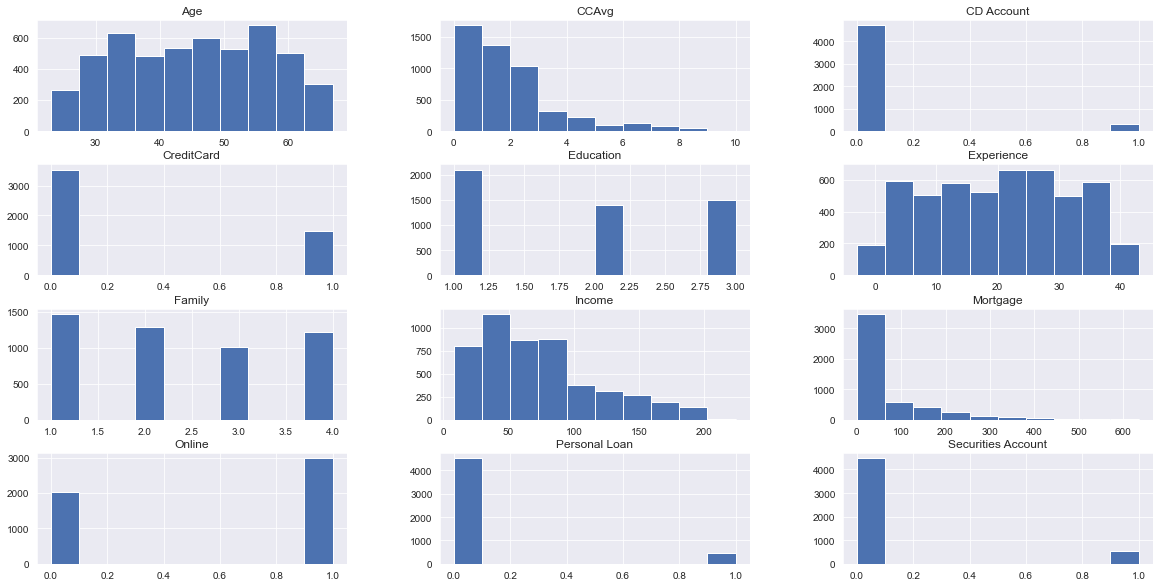

In [108]:
loan_df_dummy = loan_df.copy()
loan_df_dummy.drop(['ID', 'ZIP Code'], axis=1, inplace=True)
# Dropped these columns because they don't actually represent quantifiable values
# It doesn't make sense to compare an ID number or ZIP code as a continuous number to values in other columns

loan_df_dummy.hist(figsize=(20,10));

## Bivariate Analysis

In [109]:
# Coorelation matrix
loan_df.corr()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.008473,-0.008326,-0.017695,0.013432,-0.016797,-0.024675,0.021463,-0.013920,-0.024801,-0.016972,-0.006909,-0.002528,0.017028
Age,-0.008473,1.000000,0.994215,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,-0.008326,0.994215,1.000000,-0.046574,-0.028626,-0.052563,-0.050077,0.013152,-0.010582,-0.007413,-0.001232,0.010353,0.013898,0.008967
Income,-0.017695,-0.055269,-0.046574,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,0.013432,-0.029216,-0.028626,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.016797,-0.046418,-0.052563,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.024675,-0.052012,-0.050077,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.021463,0.041334,0.013152,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.013920,-0.012539,-0.010582,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.024801,-0.007726,-0.007413,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802


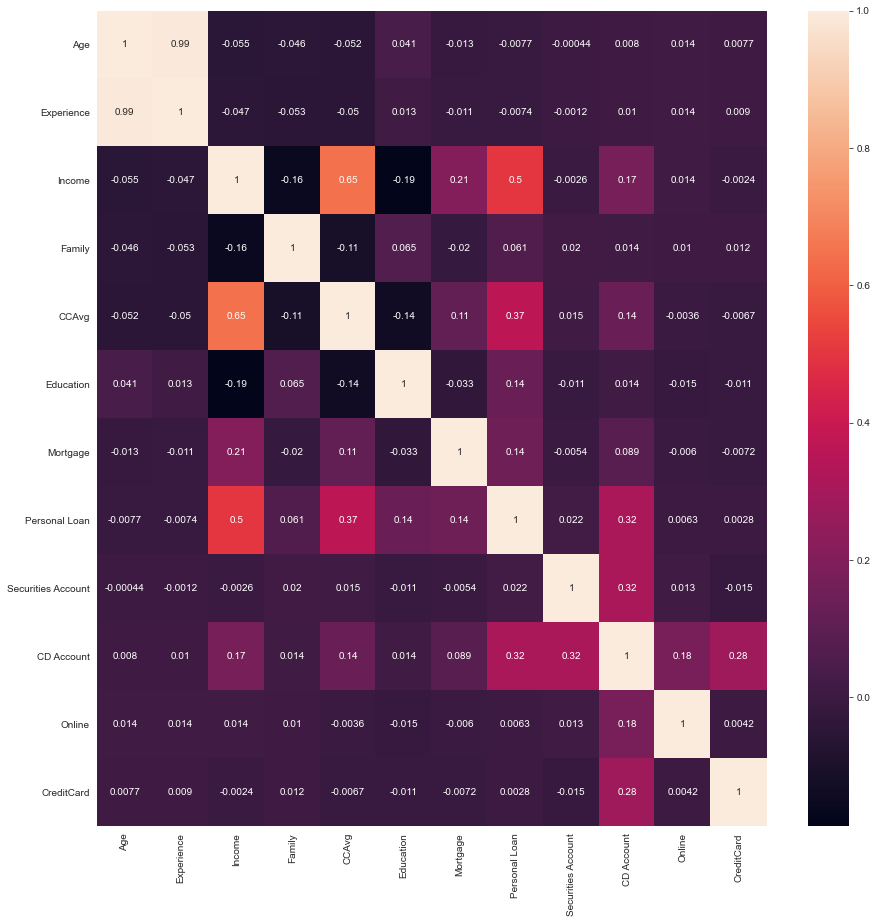

In [110]:
# Heatmap
sns.set({'figure.figsize': (15,15)})
sns.heatmap(loan_df_dummy.corr(), annot=True);

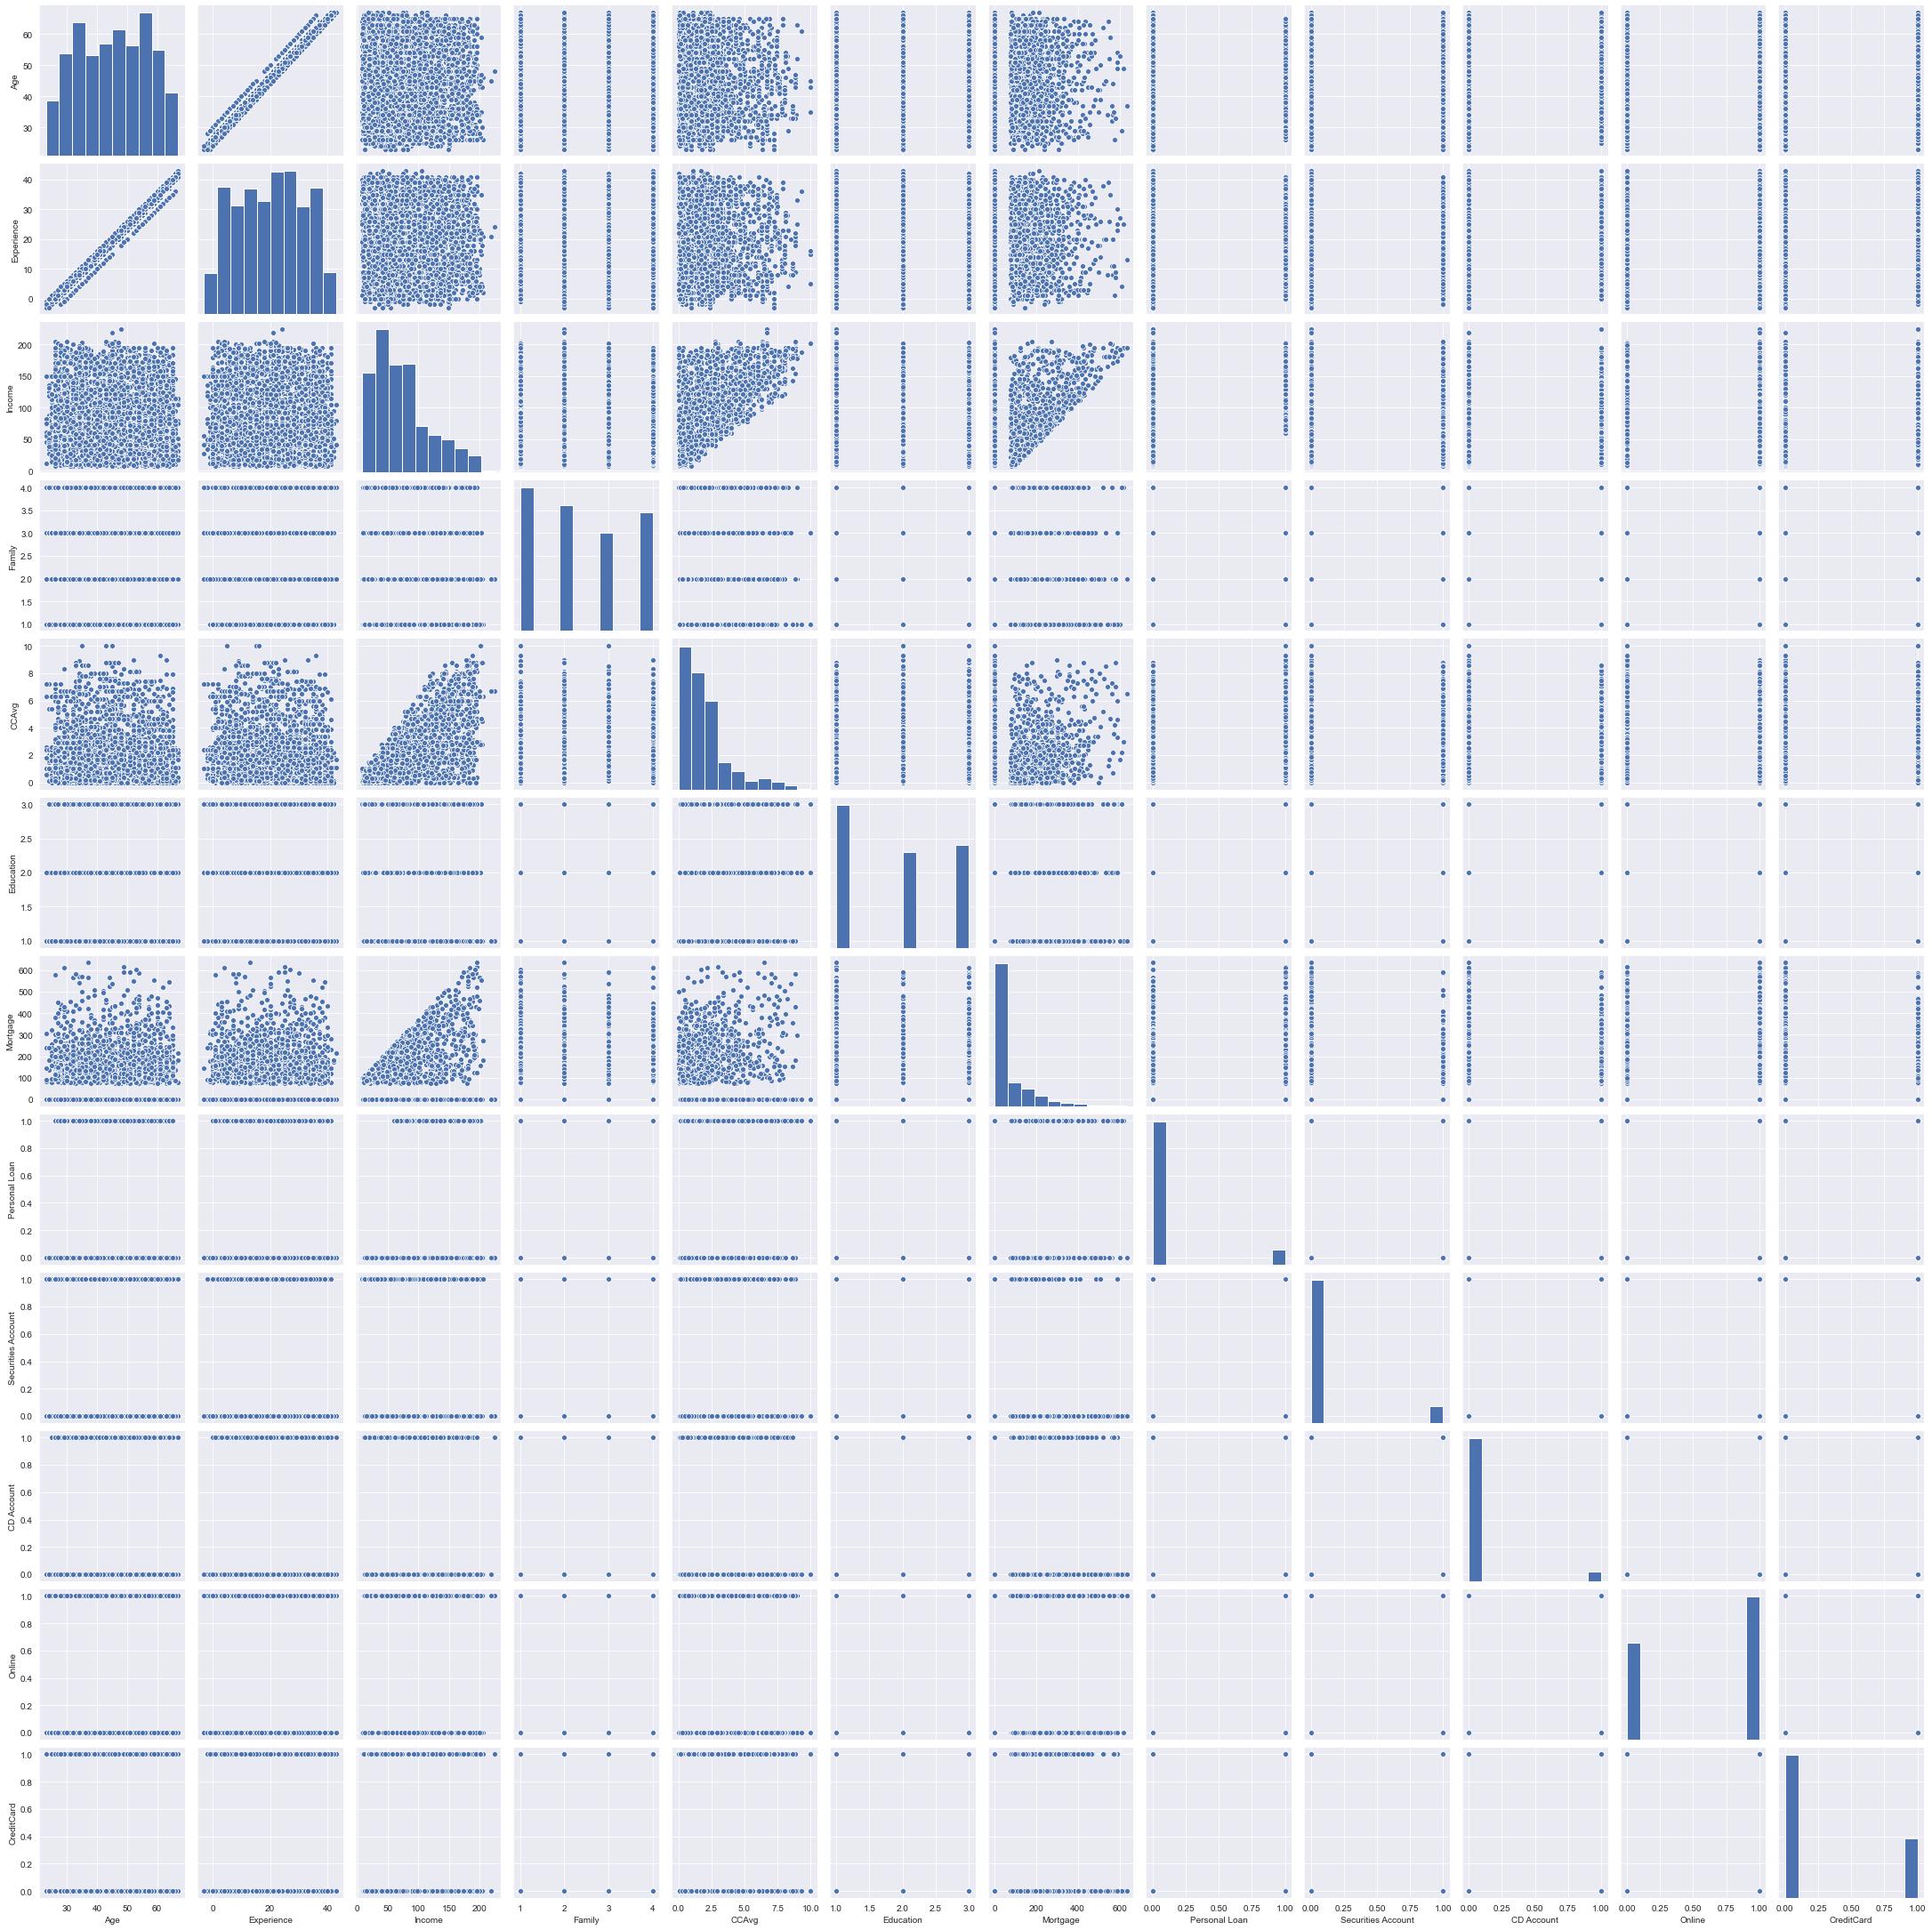

In [111]:
# Pairplot
sns.pairplot(loan_df_dummy);

In [112]:
# As we can see, there is some colinearity between Age and Experience columns. 
# A logistic regression model should have little to no colinearity
# Dropping Age column
loan_df_dummy.drop('Age', axis=1, inplace=True)

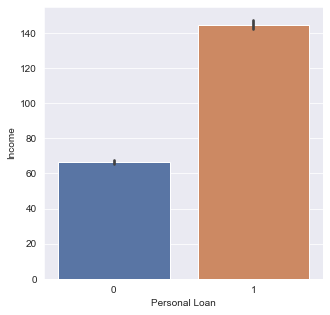

In [113]:
# Theese columns seemed to coorelate most with Personal Loan
sns.set({'figure.figsize': (5,5)})
sns.barplot(loan_df['Personal Loan'], loan_df['Income']);

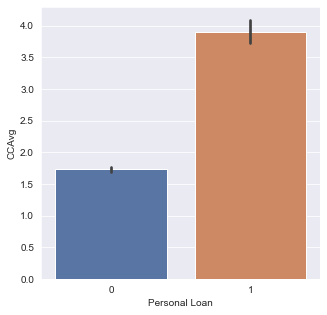

In [114]:
sns.barplot(loan_df['Personal Loan'], loan_df['CCAvg']);

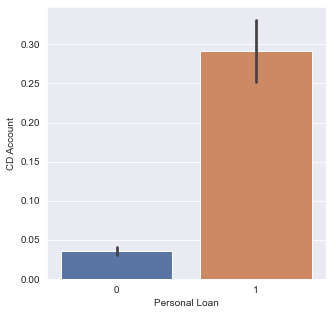

In [115]:
sns.barplot(loan_df['Personal Loan'], loan_df['CD Account']);

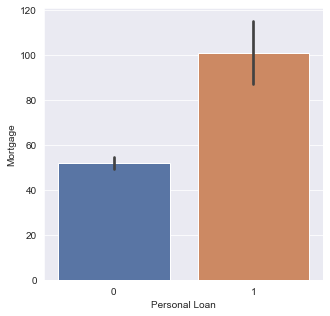

In [116]:
sns.barplot(loan_df['Personal Loan'], loan_df['Mortgage']);

## Model Building/Preprocessing

In [117]:
# Identifying duplicates
duplicates = loan_df.duplicated()
sum(duplicates)

0

In [118]:
# Normally, I would check here for null values. 
# However, I already checked for null values above per the asignment instructions.

## Checking for Outliers

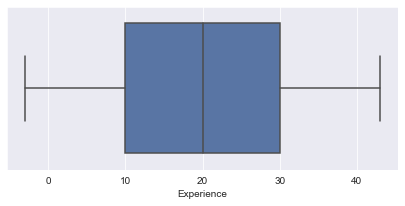

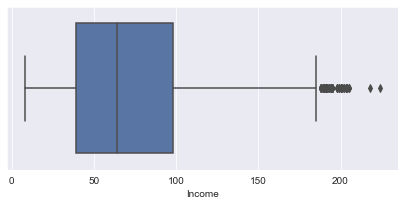

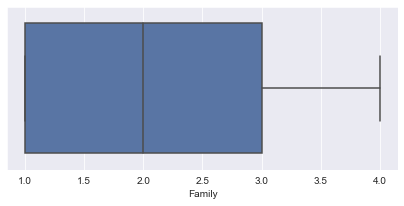

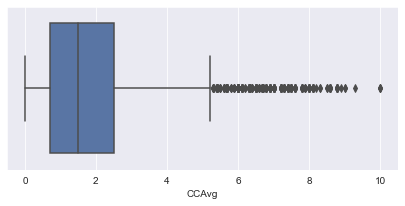

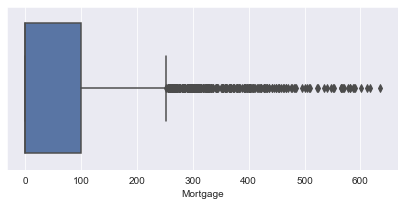

In [119]:
# Boxpots
sns.set({'figure.figsize': (7,3)})
for i in ['Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']:    # Dropped Age column
    sns.boxplot(loan_df_dummy[i]);
    plt.show()

In [120]:
## Bivariate Scatterplots

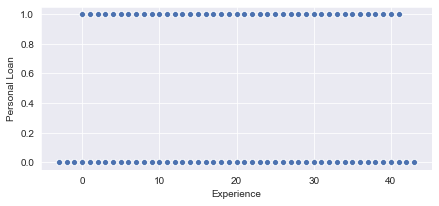

In [121]:
sns.scatterplot(loan_df_dummy['Experience'], loan_df_dummy['Personal Loan']);

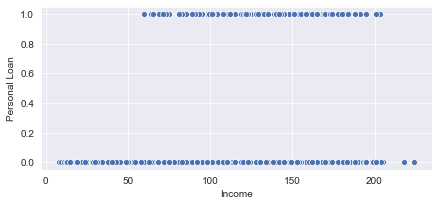

In [122]:
sns.scatterplot(loan_df_dummy['Income'], loan_df_dummy['Personal Loan']);

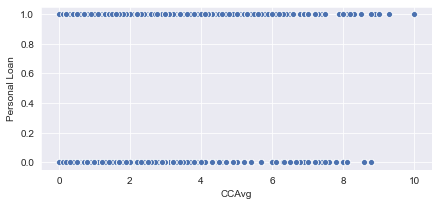

In [123]:
sns.scatterplot(loan_df_dummy['CCAvg'], loan_df_dummy['Personal Loan']);

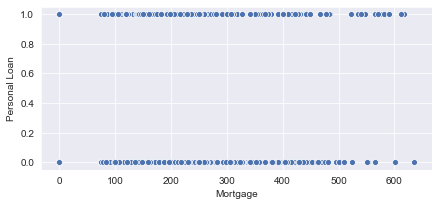

In [124]:
sns.scatterplot(loan_df_dummy['Mortgage'], loan_df_dummy['Personal Loan']);

In [125]:
# It seems like there are indeed some outliers
# Time to remove the outliers

# First, need to create some new dataframes, and drop categorical columns.
loan_df_processed = loan_df_dummy.copy()

loan_zscore = np.abs(stats.zscore(loan_df_dummy)) # Give me the zcore of every value in the df in array

for i, j in zip(np.where(loan_zscore > 3)[0], np.where(loan_zscore > 3)[1]):
    loan_df_processed.iloc[i,j] = loan_df_processed.iloc[:,j].median()

## Checking Outliers

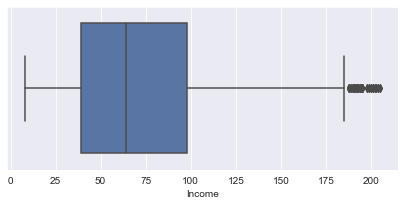

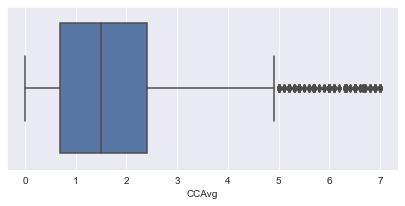

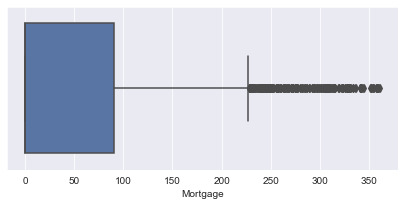

In [126]:
sns.set({'figure.figsize': (7,3)})

for i in ['Income', 'CCAvg', 'Mortgage']:
    sns.boxplot(loan_df_processed[i]);
    plt.show()

In [127]:
# As we can see, the furthest outliers from the whiskers have now been eliminated, and new outliers have emerged.

In [128]:
loan_df_processed.head(10)

,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,49.0,4,1.6,1,0.0,0.0,1,0.0,0,0
1,19,34.0,3,1.5,1,0.0,0.0,1,0.0,0,0
2,15,11.0,1,1.0,1,0.0,0.0,0,0.0,0,0
3,9,100.0,1,2.7,2,0.0,0.0,0,0.0,0,0
4,8,45.0,4,1.0,2,0.0,0.0,0,0.0,0,1
5,13,29.0,4,0.4,2,155.0,0.0,0,0.0,1,0
6,27,72.0,2,1.5,2,0.0,0.0,0,0.0,1,0
7,24,22.0,1,0.3,3,0.0,0.0,0,0.0,0,1
8,10,81.0,3,0.6,2,104.0,0.0,0,0.0,1,0
9,9,180.0,1,1.5,3,0.0,0.0,0,0.0,0,0


In [129]:
# It seems that removing outliers has destroyed the categorical columns.
# I will address this later.

In [130]:
#Scaling the Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [131]:
# Standard Scaler, only columns of continuous variables

loan_df_numerical = loan_df_processed.copy()
loan_df_numerical.drop('Family', axis=1, inplace=True)
loan_df_numerical.drop('Education', axis=1, inplace=True)
loan_df_numerical.drop('Personal Loan', axis=1, inplace=True)
loan_df_numerical.drop('Securities Account', axis=1, inplace=True)
loan_df_numerical.drop('CD Account', axis=1, inplace=True)
loan_df_numerical.drop('Online', axis=1, inplace=True)
loan_df_numerical.drop('CreditCard', axis=1, inplace=True)

In [132]:
loan_df_numerical.head()

,Experience,Income,CCAvg,Mortgage
0,1,49.0,1.6,0.0
1,19,34.0,1.5,0.0
2,15,11.0,1.0,0.0
3,9,100.0,2.7,0.0
4,8,45.0,1.0,0.0


In [133]:
# Store column names for later use
cols = loan_df_numerical.columns.tolist()
cols

['Experience', 'Income', 'CCAvg', 'Mortgage']

In [134]:
# Scaling
loan_df_numerical = scaler.fit_transform(loan_df_numerical)

In [135]:
loan_df_numerical

array([[-1.66607847, -0.53796239, -0.12441521, -0.5647345 ],
       [-0.09633022, -0.86450948, -0.19238755, -0.5647345 ],
       [-0.44516316, -1.36521502, -0.53224925, -0.5647345 ],
       ...,
       [ 1.64783451, -1.08220754, -1.00805562, -0.5647345 ],
       [ 1.73504275, -0.53796239, -0.87211094, -0.5647345 ],
       [-1.40445376,  0.20221102, -0.66819393, -0.5647345 ]])

In [136]:
# Back to df, using original column names
loan_df_numerical = pd.DataFrame(loan_df_numerical, columns = cols)
loan_df_numerical.head()

,Experience,Income,CCAvg,Mortgage
0,-1.666078,-0.537962,-0.124415,-0.564735
1,-0.096330,-0.864509,-0.192388,-0.564735
2,-0.445163,-1.365215,-0.532249,-0.564735
3,-0.968413,0.572298,0.623281,-0.564735
4,-1.055621,-0.625042,-0.532249,-0.564735


In [137]:
loan_df_processed.head()

,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,49.0,4,1.6,1,0.0,0.0,1,0.0,0,0
1,19,34.0,3,1.5,1,0.0,0.0,1,0.0,0,0
2,15,11.0,1,1.0,1,0.0,0.0,0,0.0,0,0
3,9,100.0,1,2.7,2,0.0,0.0,0,0.0,0,0
4,8,45.0,4,1.0,2,0.0,0.0,0,0.0,0,1


In [138]:
# Adding back numerical columns
loan_df_processed['Experience'] = loan_df_numerical['Experience']
loan_df_processed['Income'] = loan_df_numerical['Income']
loan_df_processed['CCAvg'] = loan_df_numerical['CCAvg']
loan_df_processed['Mortgage'] = loan_df_numerical['Mortgage']

loan_df_processed

,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,-1.666078,-0.537962,4,-0.124415,1,-0.564735,0.0,1,0.0,0,0
1,-0.096330,-0.864509,3,-0.192388,1,-0.564735,0.0,1,0.0,0,0
2,-0.445163,-1.365215,1,-0.532249,1,-0.564735,0.0,0,0.0,0,0
3,-0.968413,0.572298,1,0.623281,2,-0.564735,0.0,0,0.0,0,0
4,-1.055621,-0.625042,4,-0.532249,2,-0.564735,0.0,0,0.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.491662,-0.733891,1,0.079502,3,-0.564735,0.0,0,0.0,1,0
4996,-1.404454,-1.278136,4,-0.940083,1,0.456390,0.0,0,0.0,1,0
4997,1.647835,-1.082208,2,-1.008056,3,-0.564735,0.0,0,0.0,0,0
4998,1.735043,-0.537962,3,-0.872111,2,-0.564735,0.0,0,0.0,1,0


In [139]:
# It seems some of the categorical columns have been changed to float datatype, strange.

In [140]:
loan_df_processed['Personal Loan'] = loan_df_processed['Personal Loan'].astype('int64')
loan_df_processed['CD Account'] = loan_df_processed['CD Account'].astype('int64')

In [141]:
loan_df_processed.dtypes

Experience            float64
Income                float64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage              float64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

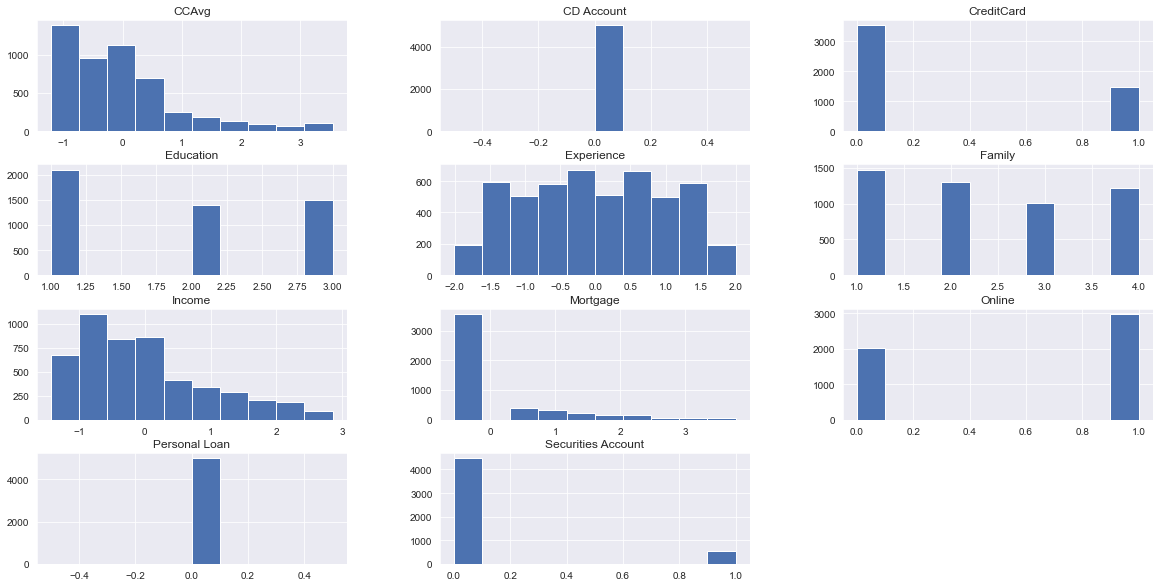

In [142]:
loan_df_processed.hist(figsize=(20,10));

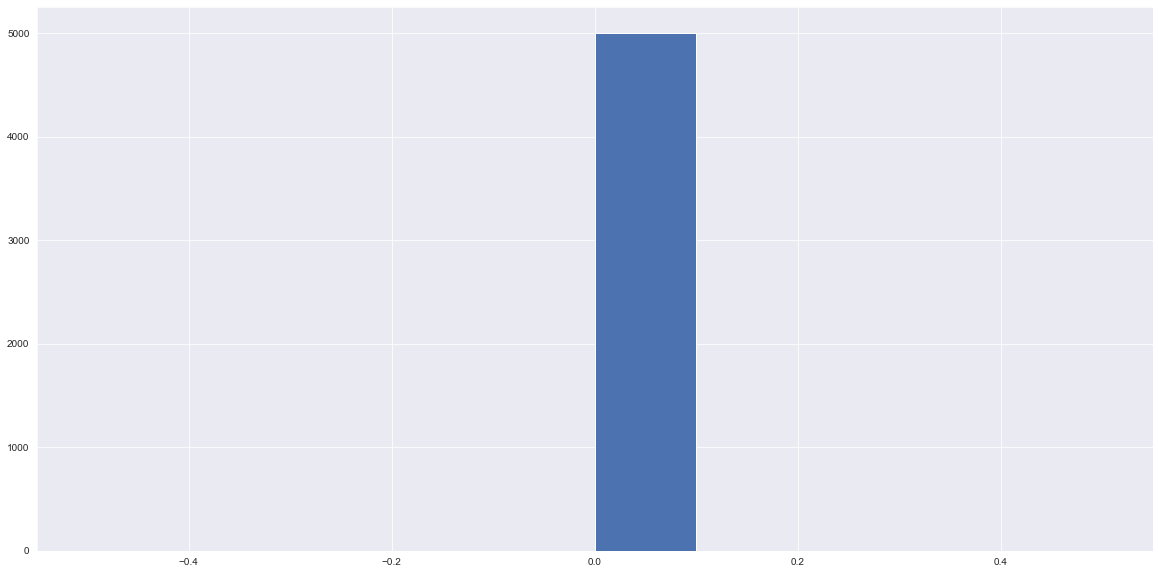

In [143]:
loan_df_processed['Personal Loan'].hist(figsize=(20,10));

In [144]:
# This is no good
# We see what removing outliers has done to the data. 

In [145]:
loan_df_processed['Personal Loan'] = loan_df_dummy['Personal Loan']
loan_df_processed['CD Account'] = loan_df_dummy['CD Account']
loan_df_processed.head(10)

,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,-1.666078,-0.537962,4,-0.124415,1,-0.564735,0,1,0,0,0
1,-0.096330,-0.864509,3,-0.192388,1,-0.564735,0,1,0,0,0
2,-0.445163,-1.365215,1,-0.532249,1,-0.564735,0,0,0,0,0
3,-0.968413,0.572298,1,0.623281,2,-0.564735,0,0,0,0,0
4,-1.055621,-0.625042,4,-0.532249,2,-0.564735,0,0,0,0,1
5,-0.619580,-0.973359,4,-0.940083,2,1.297315,0,0,0,1,0
6,0.601336,-0.037257,2,-0.192388,2,-0.564735,0,0,0,1,0
7,0.339711,-1.125747,1,-1.008056,3,-0.564735,0,0,0,0,1
8,-0.881204,0.158671,3,-0.804139,2,0.684641,0,0,0,1,0
9,-0.968413,2.313882,1,-0.192388,3,-0.564735,1,0,0,0,0


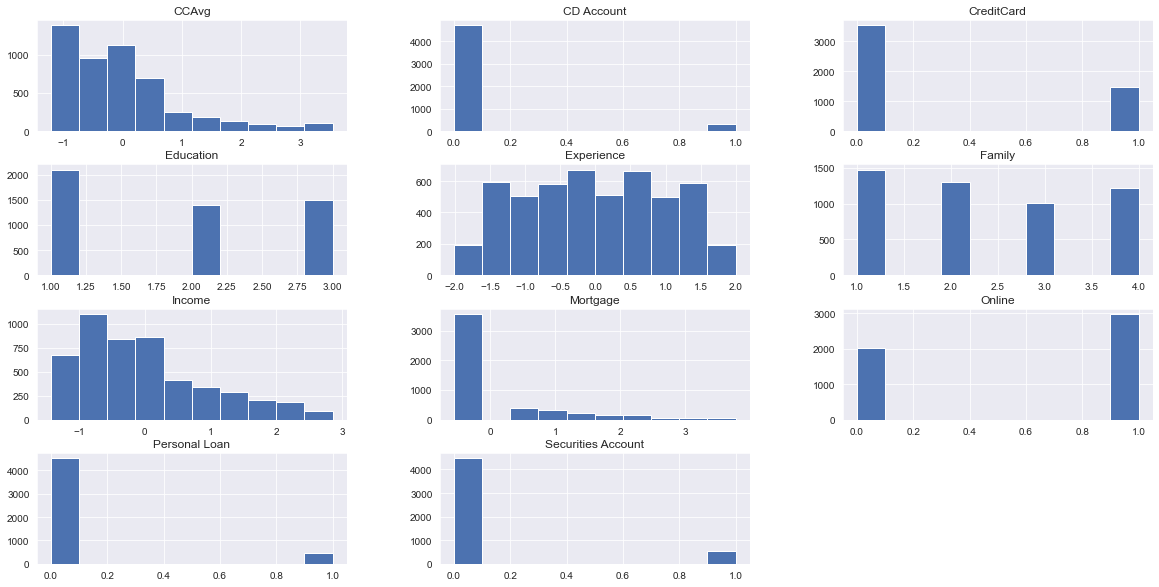

In [146]:
# Back to normal
loan_df_processed.hist(figsize=(20,10));

In [147]:
# Examine relationship of ZIP Codes to Personal Loans

In [148]:
loan_df.groupby('ZIP Code')['Personal Loan'].mean().sort_values(ascending = False).head(50)

ZIP Code
95135    0.666667
96008    0.666667
94108    0.500000
94705    0.500000
91129    0.500000
90059    0.500000
90016    0.500000
92056    0.500000
93022    0.400000
93111    0.333333
92834    0.333333
93311    0.333333
90057    0.333333
91355    0.333333
90027    0.333333
92106    0.333333
90049    0.333333
90650    0.333333
90502    0.333333
90640    0.333333
93403    0.333333
93955    0.333333
91302    0.333333
94803    0.333333
94553    0.333333
94928    0.333333
92614    0.333333
93720    0.333333
95192    0.333333
92007    0.307692
92646    0.300000
95032    0.300000
92333    0.285714
95138    0.285714
92220    0.285714
91423    0.285714
94114    0.285714
94536    0.250000
95354    0.250000
90065    0.250000
90601    0.250000
93003    0.250000
95010    0.250000
95758    0.250000
91614    0.250000
95741    0.250000
93108    0.250000
95125    0.250000
95828    0.250000
92672    0.250000
Name: Personal Loan, dtype: float64

In [149]:
loan_df.groupby('ZIP Code')['Personal Loan'].sum().sort_values(ascending = False).head(30)

ZIP Code
94720    19
94305    13
92093     9
90089     8
94304     8
90095     8
92182     7
95616     6
94022     6
95051     6
94928     5
91380     5
95814     5
95054     5
92037     5
90245     5
95039     4
95014     4
93106     4
94596     4
93407     4
93943     4
91711     4
93955     4
92007     4
94025     4
95060     4
92612     4
92028     4
91355     4
Name: Personal Loan, dtype: int64

In [150]:
# Above, we can see the zip codes most closely coorelated with Personal Loan.
# I have chosen to one-hot encode all of the zip codes.

In [151]:
dummies = pd.get_dummies(loan_df['ZIP Code'])
dummies

,9307,90005,90007,90009,90011,90016,90018,90019,90024,90025,...,95973,96001,96003,96008,96064,96091,96094,96145,96150,96651
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [152]:
# Merge the Dataframe of one-hot encoded zipcodes back to the original Dataframe
loan_df_encoded = pd.merge(loan_df_processed, dummies, how='inner', left_index=True, right_index=True)
loan_df_encoded

,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,...,95973,96001,96003,96008,96064,96091,96094,96145,96150,96651
0,-1.666078,-0.537962,4,-0.124415,1,-0.564735,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-0.096330,-0.864509,3,-0.192388,1,-0.564735,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.445163,-1.365215,1,-0.532249,1,-0.564735,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.968413,0.572298,1,0.623281,2,-0.564735,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-1.055621,-0.625042,4,-0.532249,2,-0.564735,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.491662,-0.733891,1,0.079502,3,-0.564735,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4996,-1.404454,-1.278136,4,-0.940083,1,0.456390,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4997,1.647835,-1.082208,2,-1.008056,3,-0.564735,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4998,1.735043,-0.537962,3,-0.872111,2,-0.564735,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [153]:
loan_df_processed

,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,-1.666078,-0.537962,4,-0.124415,1,-0.564735,0,1,0,0,0
1,-0.096330,-0.864509,3,-0.192388,1,-0.564735,0,1,0,0,0
2,-0.445163,-1.365215,1,-0.532249,1,-0.564735,0,0,0,0,0
3,-0.968413,0.572298,1,0.623281,2,-0.564735,0,0,0,0,0
4,-1.055621,-0.625042,4,-0.532249,2,-0.564735,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.491662,-0.733891,1,0.079502,3,-0.564735,0,0,0,1,0
4996,-1.404454,-1.278136,4,-0.940083,1,0.456390,0,0,0,1,0
4997,1.647835,-1.082208,2,-1.008056,3,-0.564735,0,0,0,0,0
4998,1.735043,-0.537962,3,-0.872111,2,-0.564735,0,0,0,1,0


In [154]:
# After comparing the df with dummies added to that without,
# We now see that ZIP Code dummies have been added to the df, while preserving all of the columns.

# 3) Splitting the Data

In [155]:
from sklearn.model_selection import train_test_split

X = loan_df_encoded.drop('Personal Loan', axis=1)
y = loan_df_encoded['Personal Loan']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=3)

# 4) Logistic Regression

In [156]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, accuracy_score 
from sklearn.linear_model import LogisticRegression

In [157]:
model = LogisticRegression(random_state=1, fit_intercept=False)
model.fit(x_train, y_train)

LogisticRegression(fit_intercept=False, random_state=1)

In [158]:
y_predict = model.predict(x_test)

In [159]:
# Reverse array to display confusion matrix in heatmap right-side-up
conf_arr = metrics.confusion_matrix(y_test, y_predict, labels=[1,0])
np.flip(conf_arr)

array([[1287,   62],
       [  88,   63]])

In [160]:
def conf_mat (test, predict):
    cm = confusion_matrix(test, predict)
    sns.set({'figure.figsize': (7,7)})  # Let's make the confsion matrix a bit bigger.
    sns.heatmap(conf_arr, annot=True, fmt='0.2f', cmap='inferno', xticklabels=[1,0], yticklabels=[1,0]);
    #sns.heatmap(cm, annot=True, fmt='0.2f', cmap='Greys', xticklabels=[0,1], yticklabels=[0,1]);
    plt.ylabel('Observed')
    plt.xlabel('Predicted')
    plt.show()
    
# Favorite cmaps: Greys, gray, plasma, inferno, magma, hot, copper

Training accuracy:   0.914 

Testing accuracy:   0.9 

Recall:   0.41721854304635764 

Precision:   0.504 

F1 Score:   0.45652173913043476 

ROC AUC Score:   0.6856292863489757 

Confusion Matrix:   



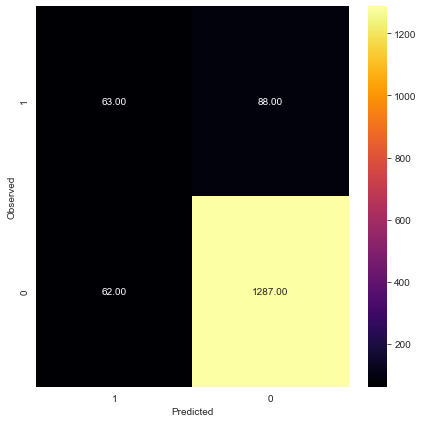

None 



In [161]:
print("Training accuracy:  ", model.score(x_train, y_train), "\n")
print("Testing accuracy:  ", model.score(x_test, y_test), "\n")
print("Recall:  ", recall_score(y_test, y_predict), "\n")
print("Precision:  ", precision_score(y_test, y_predict), "\n")
print("F1 Score:  ", f1_score(y_test, y_predict), "\n")
print("ROC AUC Score:  ", roc_auc_score(y_test, y_predict), "\n")
print("Confusion Matrix:  ", "\n"), 
print(conf_mat(y_test, y_predict), "\n")

In [162]:
from sklearn.metrics import roc_curve

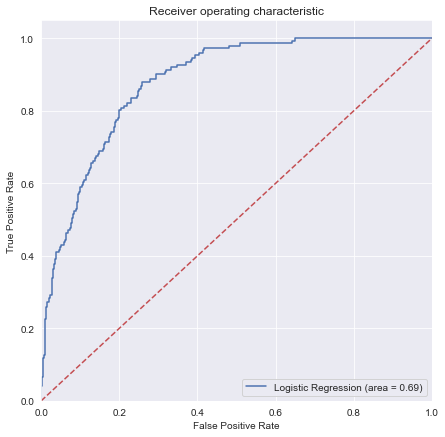

In [164]:
logit_roc_auc = roc_auc_score(y_test, model.predict(x_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# 5) Displaying Coefficients, or Feature Importance

In [165]:
F_Imp = pd.DataFrame()
F_Imp['Columns'] = x_train.columns
F_Imp['Coefficients'] = np.round(abs(model.coef_[0]),2)
F_Imp.head(10)

,Columns,Coefficients
0,Experience,0.05
1,Income,1.14
2,Family,0.43
3,CCAvg,0.25
4,Education,0.20
5,Mortgage,0.04
6,Securities Account,1.38
7,CD Account,3.99
8,Online,1.61
9,CreditCard,1.71


In [170]:
F_Imp.sort_values(by='Coefficients',ascending=False).head(20)

,Columns,Coefficients
7,CD Account,3.99
9,CreditCard,1.71
226,92780,1.62
8,Online,1.61
18,90024,1.54
263,93407,1.52
455,95819,1.50
294,94065,1.46
312,94117,1.39
6,Securities Account,1.38


# 6) Business Insights

True Positive (observed = 1, predicted = 1):

Predicted the customer will take out a loan with this bank, and the customer took out a loan with this bank.


False Positive (observed = 0, predicted = 1):

Predicted the customer will not take out a loan with this bank, and the customer took out a loan with this bank.


True Negative (observed = 0, predicted = 0):

Predicted the customer will not take out a loan with this bank, and the customer did not take out a loan with this bank.


False Negative (observed = 1, predicted = 0):

Predicted the customer will take out a loan with this bank, and the customer did not take out a loan with this bank.


Here, most of the focus was on predicting the outcome of Personal Loans, what the main forces that drive bank customers to become loan customers are. The main contributing factors were found to be the customer's zip code, income, average credit card spending, possession of a credit card, certificate of deposit (CD) account, securities account, and online account.

Recall was 48%, and precision was 50%, so the data model needs to be improved.

